# Hazmat Classifier — Analysis & Results

## The Problem
Mercado Libre processes **95 sales per second** (~8.2M transactions/day). Every product entering the logistics network must be classified as hazardous material (hazmat) before shipping — flammable liquids, lithium batteries, corrosive chemicals, compressed gases.

A missed hazmat item in a warehouse is a **safety incident**. A false positive blocks a legitimate seller. The system needs to be fast (<100ms), accurate (F1 > 0.90), and explainable.

## The Solution
An ensemble ML pipeline with fine-tuned semantic embeddings and LLM fallback:
1. **Collect** ~100k real product listings from Mercado Libre API
2. **Label** 10k items via Gemini 3.0 Flash (async multi-item prompts)
3. **Fine-tune** multilingual-e5-base embeddings for hazmat domain
4. **Train** XGBoost + LightGBM + Random Forest ensemble (Optuna-tuned)
5. **Classify** all 100k items — ML handles 94.3%, LLM fallback for 5.7%
6. **Explain** every decision via SHAP + Platt-calibrated confidence scores

In [3]:
import os
os.environ['OMP_NUM_THREADS'] = '1'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

df = pd.read_parquet('../data/output/hazmat_classified_100k.parquet')
cat_col = 'domain_id'
print(f'Dataset: {len(df):,} items | {df[cat_col].nunique()} categories')
print(f'Columns: {list(df.columns)}')

Dataset: 100,936 items | 1726 categories
Columns: ['item_id', 'title', 'description', 'is_hazmat', 'reason', 'domain_id', 'confidence_score', 'source_layer', 'ensemble_proba', 'needs_human_review', 'proba_xgboost', 'proba_lightgbm', 'proba_random_forest']


---
## 1. Classification Overview
How many items are hazmat? Who classified them — the ML ensemble or the LLM?

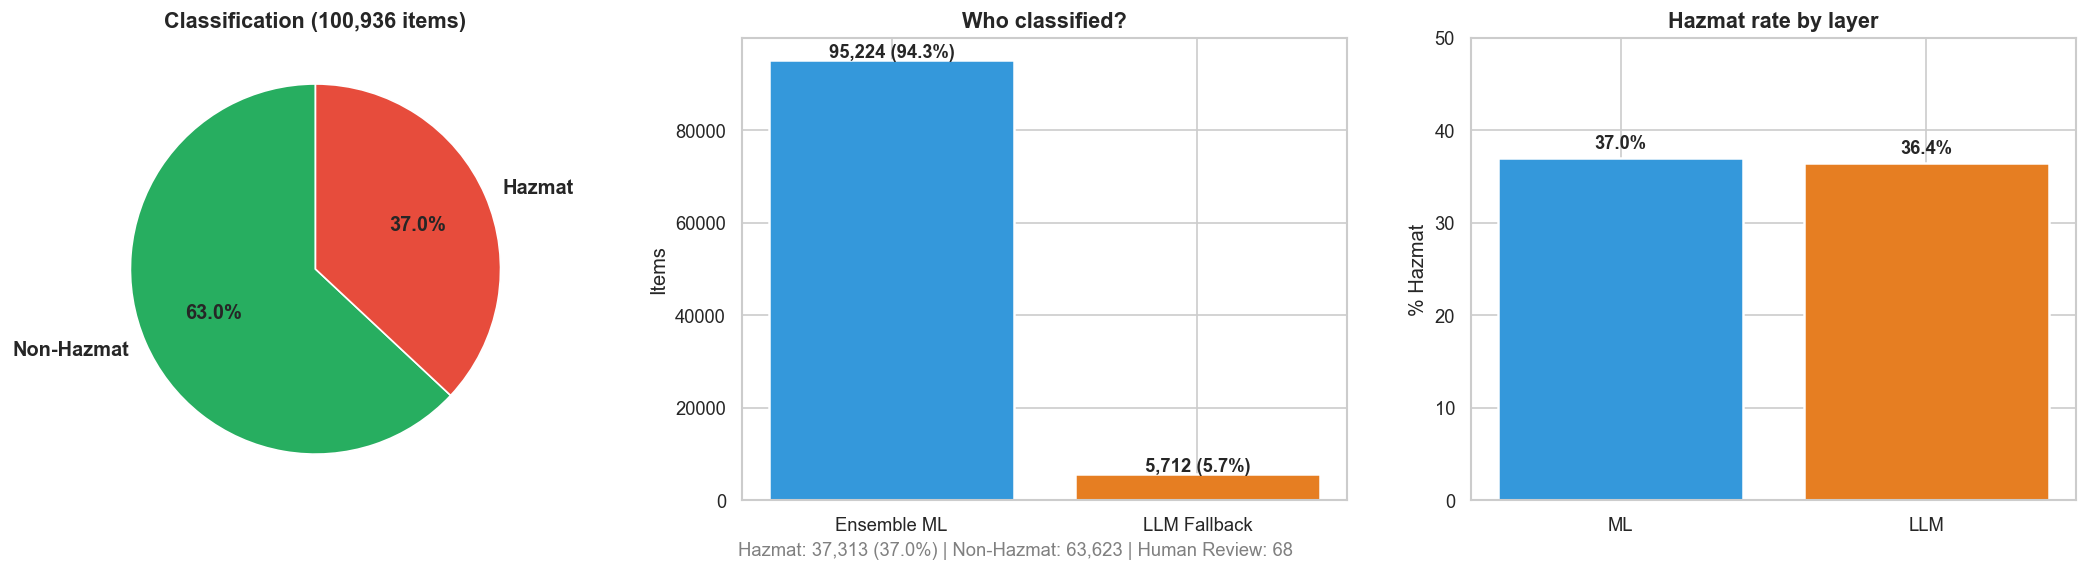


Key insight: The ensemble ML resolves 94.3% of items without any LLM call.
Only 5.7% require the more expensive LLM fallback.
In production at 95 req/s, this means ~89 req/s handled by ML alone (<10ms each).


In [4]:
hazmat = df['is_hazmat'].sum()
total = len(df)
ml_count = (df['source_layer'] == 'ml').sum()
llm_count = (df['source_layer'] == 'llm').sum()
hr_count = df['needs_human_review'].sum() if 'needs_human_review' in df.columns else 0

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Hazmat split
axes[0].pie([total - hazmat, hazmat], labels=['Non-Hazmat', 'Hazmat'],
            autopct='%1.1f%%', colors=['#27ae60', '#e74c3c'], startangle=90,
            textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[0].set_title(f'Classification ({total:,} items)', fontsize=13, fontweight='bold')

# Source layer
layers = {'Ensemble ML': ml_count, 'LLM Fallback': llm_count}
colors_layer = ['#3498db', '#e67e22']
bars = axes[1].bar(layers.keys(), layers.values(), color=colors_layer, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, layers.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                f'{val:,} ({100*val/total:.1f}%)', ha='center', fontsize=11, fontweight='bold')
axes[1].set_title('Who classified?', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Items')

# Hazmat rate by source
for layer, color in zip(['ml', 'llm'], colors_layer):
    mask = df['source_layer'] == layer
    hz_rate = df.loc[mask, 'is_hazmat'].mean()
    axes[2].bar(layer.upper(), hz_rate * 100, color=color, edgecolor='white', linewidth=1.5)
    axes[2].text(axes[2].patches[-1].get_x() + axes[2].patches[-1].get_width()/2,
                hz_rate * 100 + 1, f'{hz_rate*100:.1f}%', ha='center', fontsize=11, fontweight='bold')
axes[2].set_title('Hazmat rate by layer', fontsize=13, fontweight='bold')
axes[2].set_ylabel('% Hazmat')
axes[2].set_ylim(0, 50)

plt.suptitle(f'Hazmat: {hazmat:,} ({100*hazmat/total:.1f}%) | Non-Hazmat: {total-hazmat:,} | Human Review: {hr_count}',
             fontsize=11, y=0.02, color='gray')
plt.tight_layout()
plt.show()

print(f'\nKey insight: The ensemble ML resolves {100*ml_count/total:.1f}% of items without any LLM call.')
print(f'Only {100*llm_count/total:.1f}% require the more expensive LLM fallback.')
print(f'In production at 95 req/s, this means ~{int(95*ml_count/total)} req/s handled by ML alone (<10ms each).')

---
## 2. Confidence Distribution
Confidence indicates how certain the ensemble is. Items below 0.8 were sent to the LLM.

**Platt Scaling** (logistic calibration) was applied to ensure these scores are meaningful — a 0.9 confidence truly means ~90% accuracy.

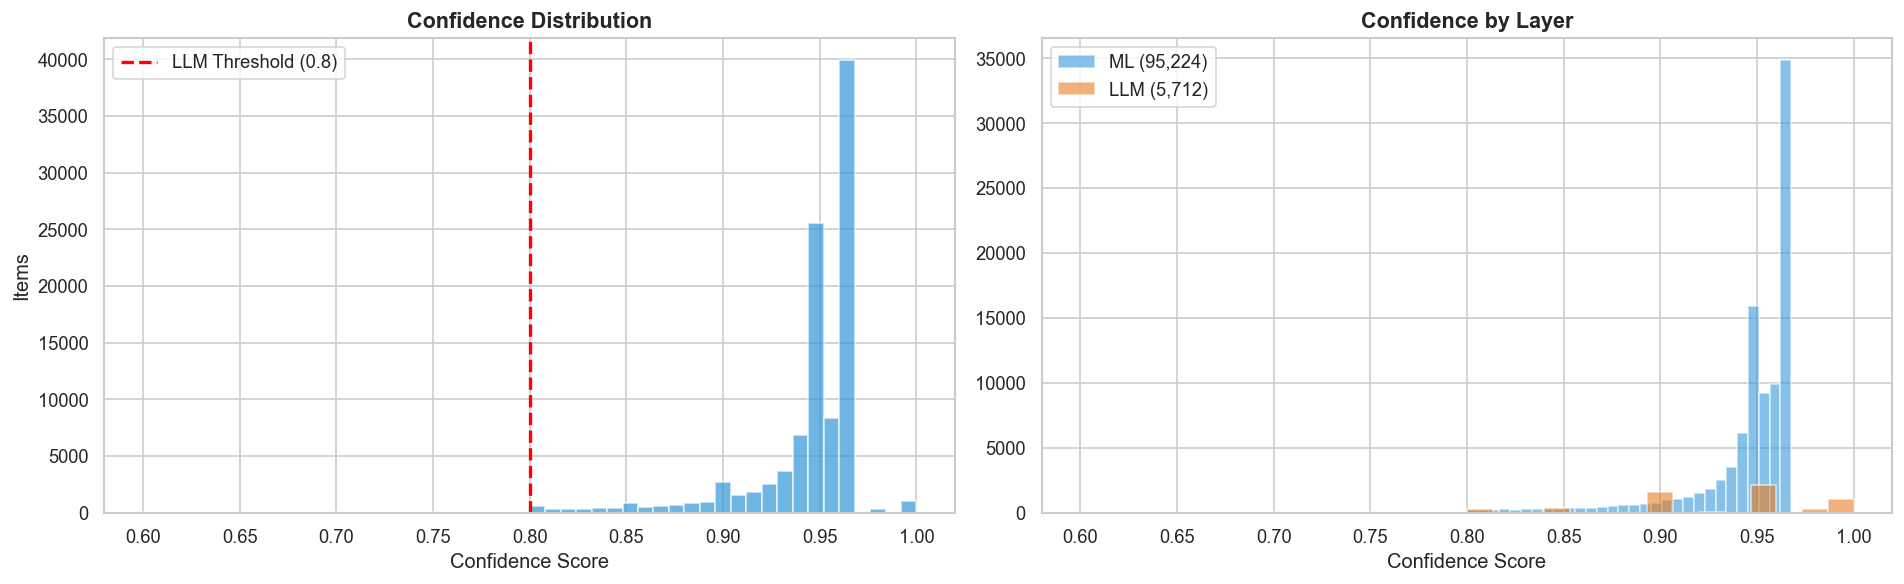

Mean confidence:     0.946
Median confidence:   0.951
ML resolved:         95,224 (94.3%)
Sent to LLM:         5,712 (5.7%)
Human review:        68 (0.07%)
Items conf < 0.8:    73 (after LLM reclassification)


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df['confidence_score'].hist(bins=50, ax=axes[0], color='#3498db', alpha=0.7, edgecolor='white')
axes[0].axvline(0.8, color='red', linestyle='--', linewidth=2, label='LLM Threshold (0.8)')
axes[0].set_title('Confidence Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Confidence Score')
axes[0].set_ylabel('Items')
axes[0].legend(fontsize=11)

for layer, color, label in [('ml', '#3498db', 'ML'), ('llm', '#e67e22', 'LLM')]:
    mask = df['source_layer'] == layer
    df.loc[mask, 'confidence_score'].hist(bins=30, ax=axes[1], alpha=0.6, color=color,
                                           label=f'{label} ({mask.sum():,})', edgecolor='white')
axes[1].set_title('Confidence by Layer', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Confidence Score')
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

llm_total = (df['source_layer'] == 'llm').sum()
ml_total = (df['source_layer'] == 'ml').sum()
hr_total = df['needs_human_review'].sum() if 'needs_human_review' in df.columns else 0

print(f'Mean confidence:     {df["confidence_score"].mean():.3f}')
print(f'Median confidence:   {df["confidence_score"].median():.3f}')
print(f'ML resolved:         {ml_total:,} ({100*ml_total/len(df):.1f}%)')
print(f'Sent to LLM:         {llm_total:,} ({100*llm_total/len(df):.1f}%)')
print(f'Human review:        {hr_total:,} ({100*hr_total/len(df):.2f}%)')
print(f'Items conf < 0.8:    {(df["confidence_score"] < 0.8).sum():,} (after LLM reclassification)')

---
## 3. Per-Model Agreement
The ensemble combines 3 models via soft voting. When all agree, confidence is high. Disagreement = ambiguity.

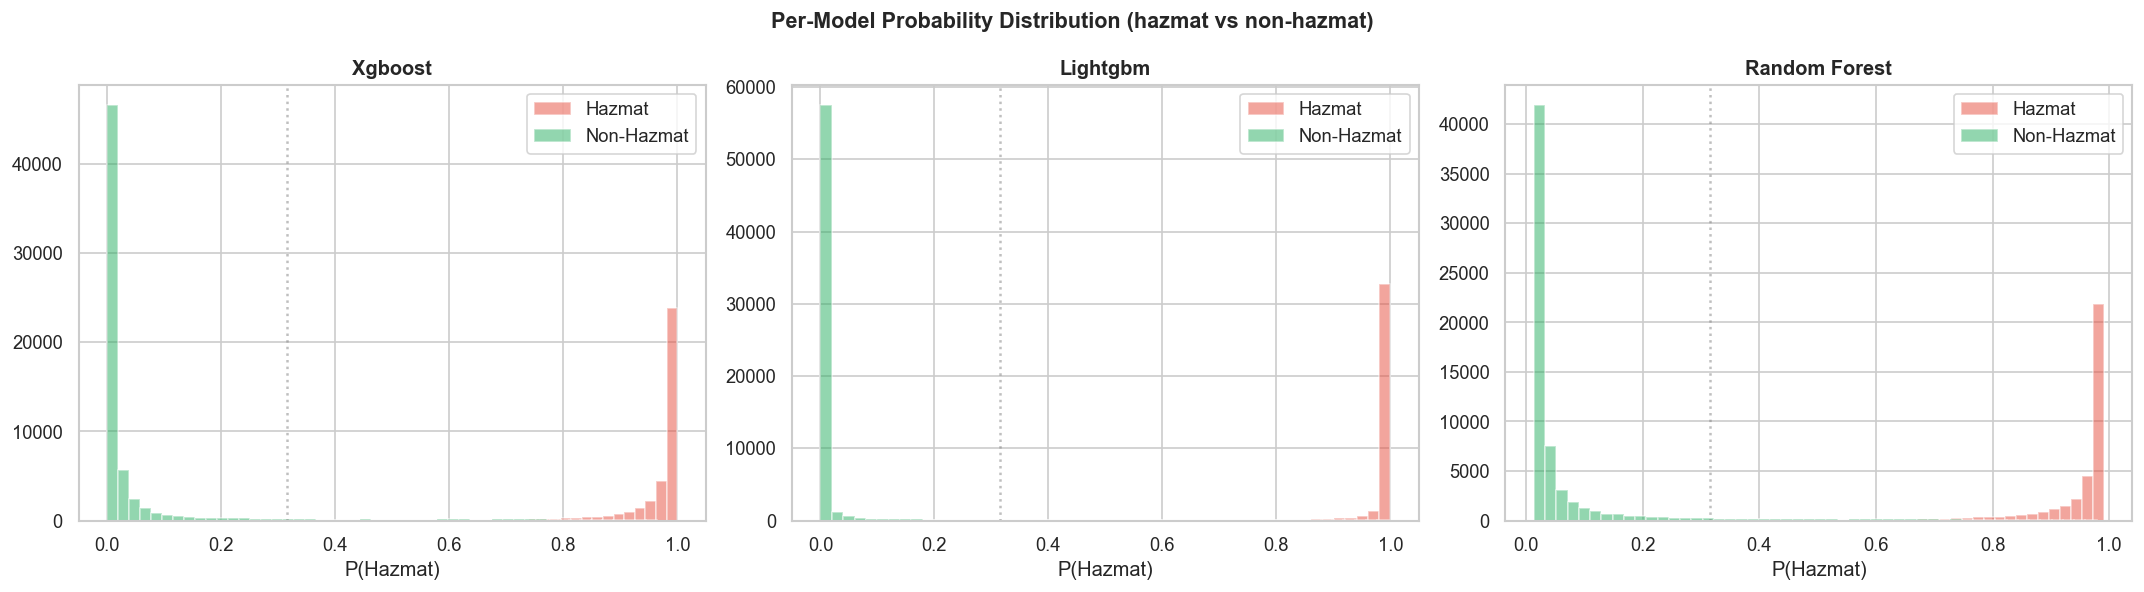

Agreement with final classification (threshold=0.315):
          xgboost: 96.7%
         lightgbm: 97.2%
    random_forest: 96.4%


In [6]:
model_cols = [c for c in df.columns if c.startswith('proba_')]
if model_cols:
    fig, axes = plt.subplots(1, len(model_cols), figsize=(6*len(model_cols), 5))
    if len(model_cols) == 1:
        axes = [axes]
    
    for ax, col in zip(axes, model_cols):
        model_name = col.replace('proba_', '').replace('_', ' ').title()
        for hz_val, label, color in [(True, 'Hazmat', '#e74c3c'), (False, 'Non-Hazmat', '#27ae60')]:
            mask = df['is_hazmat'] == hz_val
            vals = df.loc[mask, col].dropna()
            if len(vals) > 0:
                vals.hist(bins=50, ax=ax, alpha=0.5, label=label, color=color, edgecolor='white')
        ax.set_title(f'{model_name}', fontsize=12, fontweight='bold')
        ax.set_xlabel('P(Hazmat)')
        ax.axvline(0.315, color='gray', linestyle=':', alpha=0.5)
        ax.legend()
    
    plt.suptitle('Per-Model Probability Distribution (hazmat vs non-hazmat)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print('Agreement with final classification (threshold=0.315):')
    for col in model_cols:
        vals = df[col].dropna()
        model_pred = vals >= 0.315
        agreement = (model_pred == df.loc[vals.index, 'is_hazmat']).mean()
        print(f'  {col.replace("proba_", ""):>15}: {100*agreement:.1f}%')

---
## 4. SHAP Explainability
Every classification includes a human-readable reason powered by SHAP.

Let's look at what the model considers important and how it explains its decisions.

In [7]:
import warnings
warnings.filterwarnings('ignore')

# Show example reasons
print('=== HAZMAT EXAMPLES (SHAP-explained) ===')
hz_sample = df[df['is_hazmat'] == True].sample(10, random_state=42)
for _, row in hz_sample.iterrows():
    print(f'  [HAZ] conf={row["confidence_score"]:.2f} | {str(row["title"])[:55]}')
    print(f'         {str(row["reason"])[:90]}')
    print()

print('\n=== NON-HAZMAT EXAMPLES ===')
nhz_sample = df[df['is_hazmat'] == False].sample(10, random_state=42)
for _, row in nhz_sample.iterrows():
    print(f'  [OK ] conf={row["confidence_score"]:.2f} | {str(row["title"])[:55]}')
    print(f'         {str(row["reason"])[:90]}')
    print()

=== HAZMAT EXAMPLES (SHAP-explained) ===
  [HAZ] conf=0.87 | Cola Instantanea Tekbond 793 20g Rochas Aquariio C/ 3 U
         Hazmat (conf: 0.93) — semantic similarity to toxic substances

  [HAZ] conf=0.95 | Água Sanitária 5 Litros
         Hazmat (conf: 0.96) — semantic text analysis indicates hazardous material

  [HAZ] conf=0.94 | 4 Bateria 18650 Li-ion 3200mah 4.2v Lanterna Tática Led
         Hazmat (conf: 0.96) — semantic similarity to lithium/alkaline batteries

  [HAZ] conf=0.95 | Carrinho Controle Remoto Estilo Tanque Guerra Bolinha G
         Hazmat (conf: 0.96) — semantic similarity to lithium/alkaline batteries

  [HAZ] conf=0.90 | Vertex 5l Limpa Estofado Automotivo Residencial + Borri
         Hazmat (conf: 0.95) — semantic text analysis indicates hazardous material

  [HAZ] conf=0.95 | Caixa Som Karaokê Infantil Bluetooth Microfone Sem Fio 
         Hazmat (conf: 0.96) — semantic similarity to lithium/alkaline batteries

  [HAZ] conf=0.95 | Óleo de transmissão manual pa

---
## 5. LLM Fallback Analysis
5.7% of items had low ML confidence and were sent to Gemini 3.0 Flash for a second opinion.

In [8]:
llm_df = df[df['source_layer'] == 'llm']
print(f'LLM resolved: {len(llm_df):,} items ({100*len(llm_df)/len(df):.1f}%)')
print(f'  Hazmat: {llm_df["is_hazmat"].sum()} ({100*llm_df["is_hazmat"].mean():.1f}%)')
print(f'  Mean confidence: {llm_df["confidence_score"].mean():.3f}')
print()

print('Top 10 categories sent to LLM:')
llm_cats = llm_df[cat_col].value_counts().head(10)
for cat, count in llm_cats.items():
    total_cat = len(df[df[cat_col] == cat])
    print(f'  {cat}: {count} items ({100*count/total_cat:.0f}% of category)')

failed = df[df['reason'].str.contains('failed', case=False, na=False)]
print(f'\nLLM failures: {len(failed)}')

if 'needs_human_review' in df.columns:
    hr = df[df['needs_human_review'] == True]
    print(f'Items flagged for human review: {len(hr)}')

LLM resolved: 5,712 items (5.7%)
  Hazmat: 2081 (36.4%)
  Mean confidence: 0.930

Top 10 categories sent to LLM:
  MLB-HAIR_AND_FACE_DYES_AND_BLEACHES: 338 items (13% of category)
  MLB-HAIR_TREATMENTS: 322 items (12% of category)
  MLB-VEHICLE_DEGREASERS: 172 items (19% of category)
  MLB-WRISTWATCHES: 126 items (18% of category)
  MLB-VEHICLE_SHAMPOOS: 122 items (64% of category)
  MLB-GLUES_AND_ADHESIVES: 108 items (9% of category)
  MLB-PERSONAL_LUBRICANTS_AND_GELS: 97 items (29% of category)
  MLB-GAS_HEATERS: 91 items (37% of category)
  MLB-PC_KEYBOARDS: 91 items (10% of category)
  MLB-BICYCLE_CHAIN_LUBRICANTS: 89 items (23% of category)

LLM failures: 0
Items flagged for human review: 68


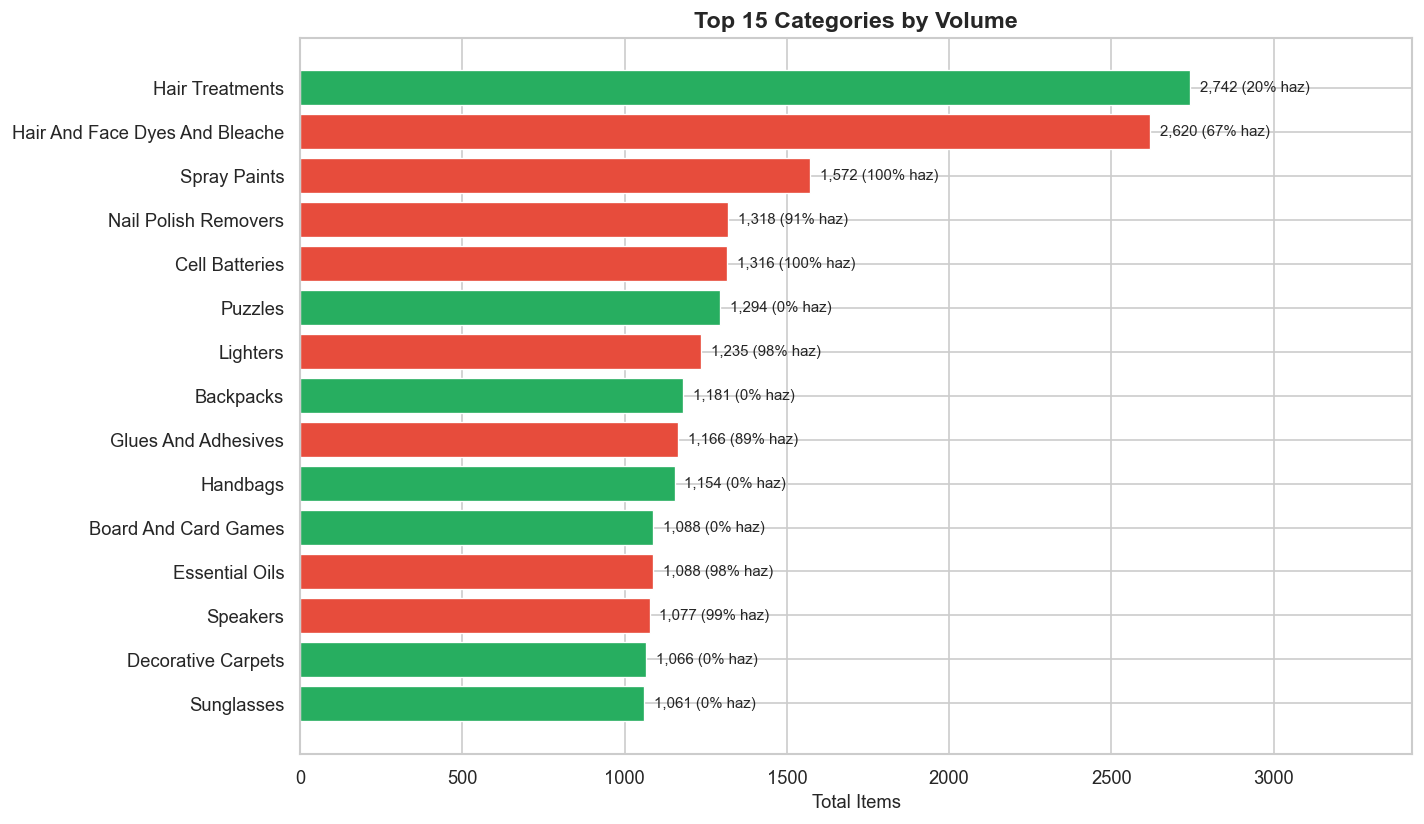

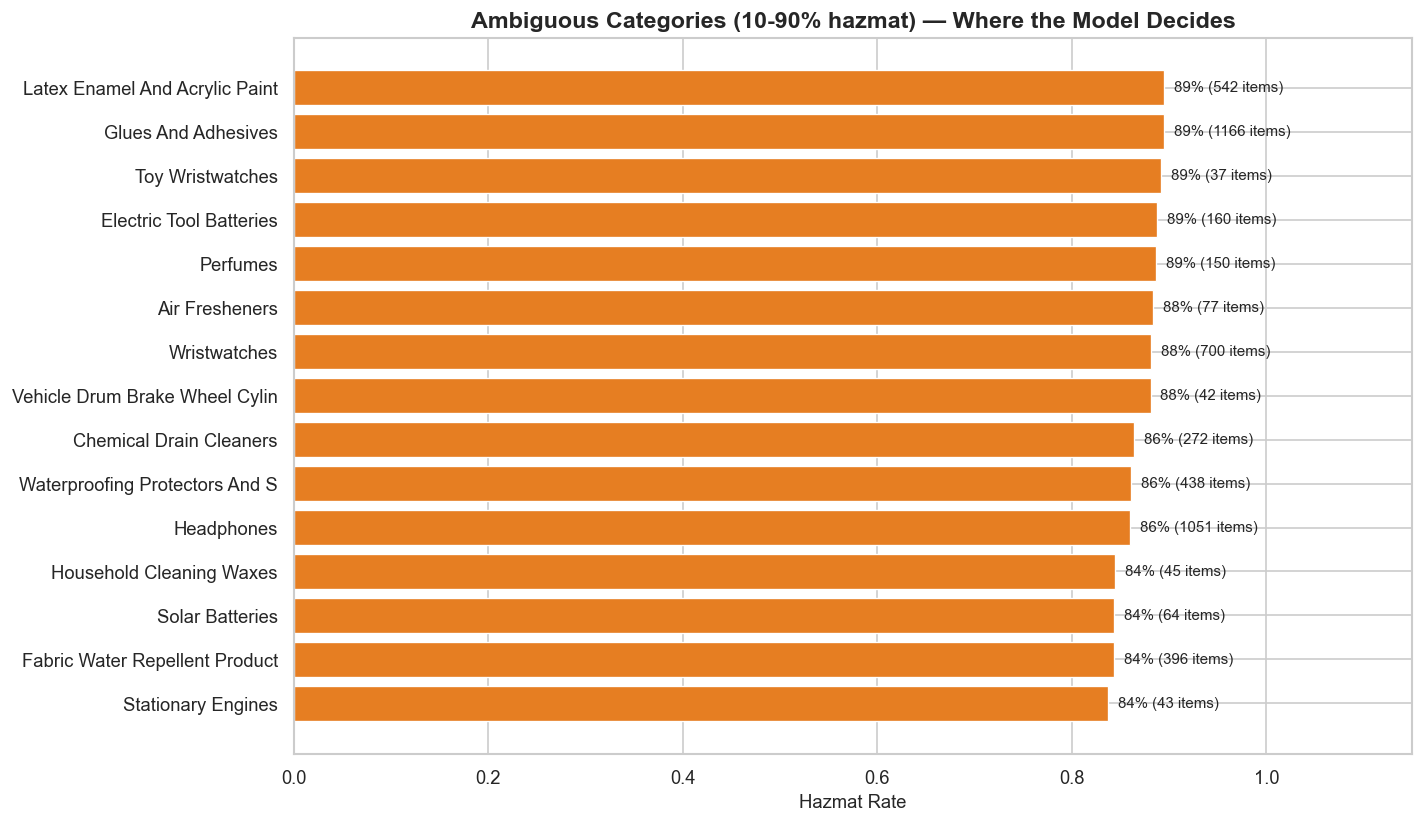

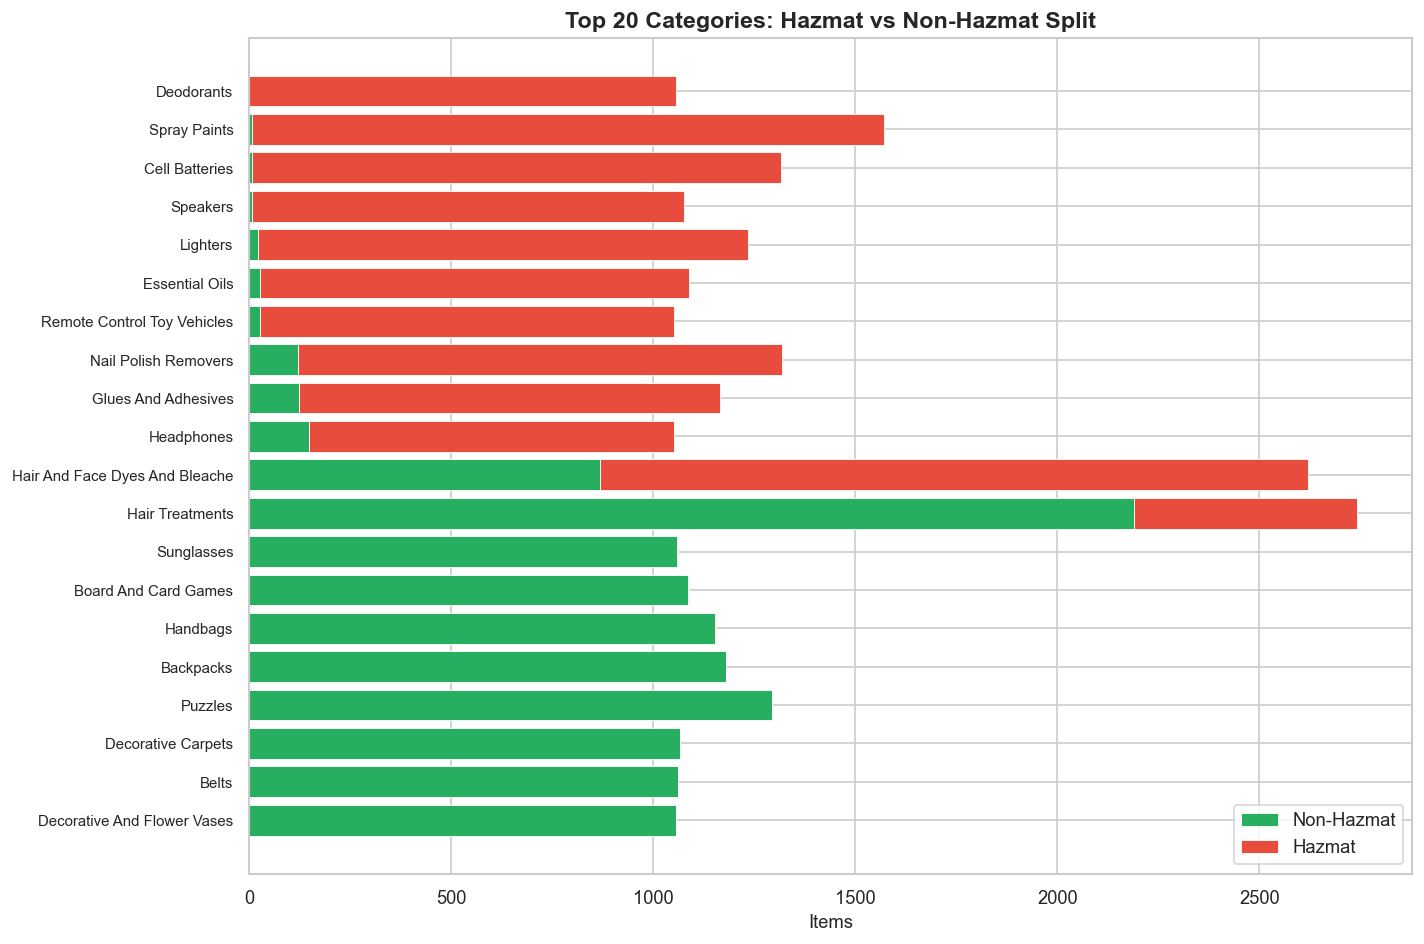

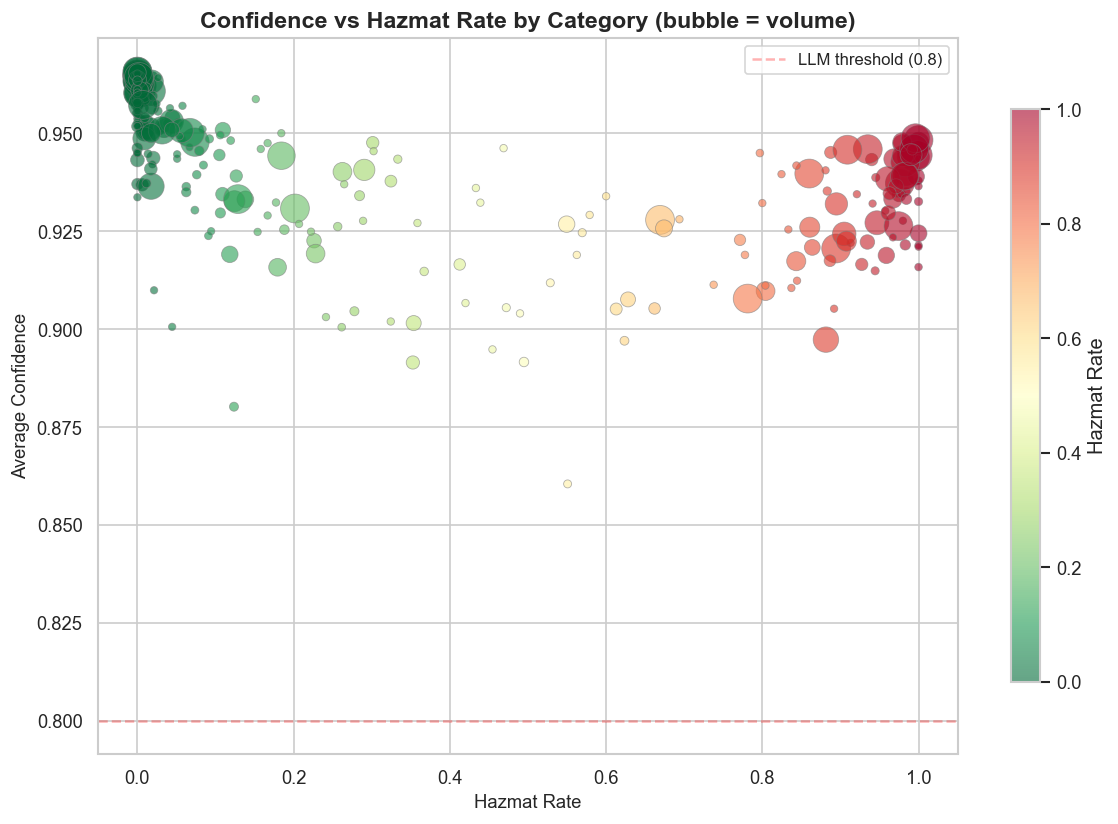

Total categories: 1726
100% hazmat: 17
0% hazmat:   121
Mixed (10-90% hazmat): 15


In [13]:
cat_stats = df.groupby(cat_col).agg(
    total=('is_hazmat', 'count'),
    hazmat=('is_hazmat', 'sum'),
    avg_conf=('confidence_score', 'mean'),
).assign(
    hazmat_rate=lambda x: x['hazmat'] / x['total'],
    non_hazmat=lambda x: x['total'] - x['hazmat'],
)

# Clean category names for display
def clean_cat(name):
    return name.replace('MLB-', '').replace('_', ' ').title()[:30]

# ── Plot 1: Top 15 by volume ──
fig, ax = plt.subplots(figsize=(12, 7))
top_vol = cat_stats.sort_values('total', ascending=True).tail(15)
colors_vol = ['#e74c3c' if r > 0.5 else '#27ae60' for r in top_vol['hazmat_rate']]
y_labels = [clean_cat(idx) for idx in top_vol.index]
ax.barh(y_labels, top_vol['total'], color=colors_vol, edgecolor='white', linewidth=0.8)
for i, (idx, row) in enumerate(top_vol.iterrows()):
    ax.text(row['total'] + 30, i, f'{int(row["total"]):,} ({row["hazmat_rate"]:.0%} haz)',
            va='center', fontsize=9)
ax.set_xlabel('Total Items', fontsize=11)
ax.set_title('Top 15 Categories by Volume', fontsize=14, fontweight='bold')
ax.set_xlim(0, top_vol['total'].max() * 1.25)
plt.tight_layout()
plt.show()

# ── Plot 2: Ambiguous categories ──
fig, ax = plt.subplots(figsize=(12, 7))
ambiguous = cat_stats[(cat_stats['total'] >= 30) & 
                       (cat_stats['hazmat_rate'] > 0.1) & 
                       (cat_stats['hazmat_rate'] < 0.9)].sort_values('hazmat_rate', ascending=True).tail(15)
if len(ambiguous) > 0:
    y_labels = [clean_cat(idx) for idx in ambiguous.index]
    ax.barh(y_labels, ambiguous['hazmat_rate'], color='#e67e22', edgecolor='white', linewidth=0.8)
    for i, (idx, row) in enumerate(ambiguous.iterrows()):
        ax.text(row['hazmat_rate'] + 0.01, i,
                f'{row["hazmat_rate"]:.0%} ({int(row["total"])} items)', va='center', fontsize=9)
    ax.set_xlim(0, 1.15)
ax.set_xlabel('Hazmat Rate', fontsize=11)
ax.set_title('Ambiguous Categories (10-90% hazmat) — Where the Model Decides', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Plot 3: Stacked hazmat vs non-hazmat ──
fig, ax = plt.subplots(figsize=(12, 8))
top_cats = cat_stats.sort_values('total', ascending=False).head(20)
top_cats_sorted = top_cats.sort_values('hazmat_rate', ascending=True)
y_labels = [clean_cat(idx) for idx in top_cats_sorted.index]
y_pos = range(len(top_cats_sorted))
ax.barh(y_pos, top_cats_sorted['non_hazmat'], color='#27ae60', label='Non-Hazmat', edgecolor='white', linewidth=0.5)
ax.barh(y_pos, top_cats_sorted['hazmat'], left=top_cats_sorted['non_hazmat'], color='#e74c3c', label='Hazmat', edgecolor='white', linewidth=0.5)
ax.set_yticks(y_pos)
ax.set_yticklabels(y_labels, fontsize=9)
ax.set_xlabel('Items', fontsize=11)
ax.set_title('Top 20 Categories: Hazmat vs Non-Hazmat Split', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
plt.tight_layout()
plt.show()

# ── Plot 4: Scatter confidence vs hazmat rate ──
fig, ax = plt.subplots(figsize=(10, 7))
big_cats = cat_stats[cat_stats['total'] >= 30]
sizes = np.clip(big_cats['total'] / 3, 20, 300)
scatter = ax.scatter(big_cats['hazmat_rate'], big_cats['avg_conf'], 
                     s=sizes, alpha=0.6, c=big_cats['hazmat_rate'],
                     cmap='RdYlGn_r', edgecolors='gray', linewidth=0.5)
ax.set_xlabel('Hazmat Rate', fontsize=11)
ax.set_ylabel('Average Confidence', fontsize=11)
ax.set_title('Confidence vs Hazmat Rate by Category (bubble = volume)', fontsize=14, fontweight='bold')
ax.axhline(0.8, color='red', linestyle='--', alpha=0.3, label='LLM threshold (0.8)')
ax.legend(fontsize=10)
plt.colorbar(scatter, ax=ax, label='Hazmat Rate', shrink=0.8)
plt.tight_layout()
plt.show()

print(f'Total categories: {len(cat_stats)}')
print(f'100% hazmat: {len(cat_stats[(cat_stats["hazmat_rate"]==1.0) & (cat_stats["total"]>=20)])}')
print(f'0% hazmat:   {len(cat_stats[(cat_stats["hazmat_rate"]==0.0) & (cat_stats["total"]>=20)])}')
print(f'Mixed (10-90% hazmat): {len(ambiguous)}')

In [10]:
labels_path = Path('../data/processed/labels_llm.parquet')
if labels_path.exists():
    labels = pd.read_parquet(labels_path)
    merged = labels[['item_id', 'is_hazmat']].merge(
        df[['item_id', 'is_hazmat', 'confidence_score', 'source_layer']],
        on='item_id', suffixes=('_label', '_pred')
    )
    
    agreement = (merged['is_hazmat_label'] == merged['is_hazmat_pred']).mean()
    disagree = merged[merged['is_hazmat_label'] != merged['is_hazmat_pred']]
    fn = disagree[(disagree['is_hazmat_label'] == True) & (disagree['is_hazmat_pred'] == False)]
    fp = disagree[(disagree['is_hazmat_label'] == False) & (disagree['is_hazmat_pred'] == True)]
    
    print(f'Training labels: {len(labels):,} ({100*labels["is_hazmat"].mean():.1f}% hazmat)')
    print(f'Agreement (label vs ensemble): {100*agreement:.1f}%')
    print(f'Disagreements: {len(disagree)} ({100*len(disagree)/len(merged):.1f}%)')
    print(f'  False Negatives (label=hazmat, ensemble=no): {len(fn)}')
    print(f'  False Positives (label=no, ensemble=hazmat): {len(fp)}')
    print(f'  Mean confidence of disagreements: {disagree["confidence_score"].mean():.3f}')
    print()
    print('The ensemble DISAGREES with Gemini in ~2% of cases.')
    print('This is expected and healthy: the ensemble generalizes from labels, it does not copy.')
    print('It may even correct LLM errors where the pattern from 10k examples is stronger than a single LLM call.')

Training labels: 10,000 (38.0% hazmat)
Agreement (label vs ensemble): 97.8%
Disagreements: 216 (2.2%)
  False Negatives (label=hazmat, ensemble=no): 128
  False Positives (label=no, ensemble=hazmat): 88
  Mean confidence of disagreements: 0.903

The ensemble DISAGREES with Gemini in ~2% of cases.
This is expected and healthy: the ensemble generalizes from labels, it does not copy.
It may even correct LLM errors where the pattern from 10k examples is stronger than a single LLM call.


---
## 6. Suspicious Cases (Audit Candidates)
Items the model might have gotten wrong — candidates for human review.

In [14]:
print('=== HAZMAT WITH LOW CONFIDENCE (possible false positives) ===')
low_hz = df[(df['is_hazmat'] == True) & (df['confidence_score'] < 0.85)].sort_values('confidence_score')
for _, row in low_hz.head(10).iterrows():
    print(f'  conf={row["confidence_score"]:.2f} | {str(row["title"])[:60]} | {str(row["reason"])[:40]}')

print()
print('=== NON-HAZMAT WITH LOW CONFIDENCE (possible false negatives — worst error) ===')
low_nhz = df[(df['is_hazmat'] == False) & (df['confidence_score'] < 0.85)].sort_values('confidence_score')
for _, row in low_nhz.head(10).iterrows():
    print(f'  conf={row["confidence_score"]:.2f} | {str(row["title"])[:60]} | {str(row["reason"])[:40]}')

=== HAZMAT WITH LOW CONFIDENCE (possible false positives) ===
  conf=0.70 | Loção Hamamélis Sofisticatto Adstringente Lubrificante Spray | Loções adstringentes de hamamélis freque
  conf=0.70 | Luz PGB Abajur | Provável dispositivo portátil com bateri
  conf=0.70 | Impermeabilizante De Tecido Da Malco Fabric Protector | Protetores de tecido profissionais frequ
  conf=0.70 | Luz Zein Luminária Abajur | Provável dispositivo portátil com bateri
  conf=0.70 | Bactericida E Fungicida Da Atlantys 15ml (kit De 3) | Tratamentos químicos para aquários (bact
  conf=0.70 | Luz DMOB ABAJUR MESA | Provável dispositivo portátil com bateri
  conf=0.70 | Luz PROIMP Abajur Aura | Provável dispositivo portátil com bateri
  conf=0.70 | Lubrificante Polidor Para Instrumentos Metais | Polidores de metais frequentemente contê
  conf=0.70 | 1x Imunehair Spray + 1x Imunehair Spray Travel - 60ml | Sprays antissépticos para cabelo geralme
  conf=0.70 | Shampoo De Tintura De Cabelo 4 Em 1 Para Cobertura De Cabel

---
## 7. Pipeline Metrics Summary

In [12]:
pm_path = Path('../data/output/pipeline_metrics.json')
lm_path = Path('../data/output/labeling_metrics.json')
cfg_path = Path('../data/output/best_ensemble_config.json')

print('=' * 65)
print('CLASSIFICATION PIPELINE')
print('=' * 65)
if pm_path.exists():
    pm = json.load(open(pm_path))
    print(f'Total classified:    {pm["total_items_classified"]:,}')
    print(f'Hazmat:              {pm["hazmat_total"]:,} ({pm["hazmat_rate"]*100:.1f}%)')
    print(f'Mean confidence:     {pm["confidence_stats"]["mean"]:.3f}')
    for layer, data in pm.get('layers', {}).items():
        pct = pm['layer_routing'].get(layer, 0) * 100
        print(f'  {layer.upper():>5}: {data["total"]:>7,} ({pct:.1f}%) | hazmat: {data["hazmat_rate"]:.1%} | conf: {data["avg_confidence"]:.3f}')
    hr = pm.get('human_review', {})
    print(f'  Human review: {hr.get("total", 0)} ({hr.get("rate", 0)*100:.2f}%)')
    print(f'  Failed items: {pm.get("failed_items", 0)}')

print()
print('=' * 65)
print('LABELING (Gemini 3.0 Flash)')
print('=' * 65)
if lm_path.exists():
    lm = json.load(open(lm_path))
    print(f'Items labeled:       {lm.get("items_labeled_this_run", "?"):,}')
    print(f'Tokens used:         {lm.get("total_tokens", 0):,}')
    print(f'Tokens saved:        ~{lm.get("tokens_saved_estimate", 0):,} (multi-item batching)')
    print(f'Throughput:          {lm.get("throughput_items_per_s", 0):.1f} items/s')
    print(f'Error rate:          {lm.get("error_rate", 0)*100:.1f}%')

print()
print('=' * 65)
print('ENSEMBLE (Optuna-tuned)')
print('=' * 65)
if cfg_path.exists():
    cfg = json.load(open(cfg_path))
    print(f'Best F1:             {cfg.get("score", 0):.4f}')
    print(f'Recall:              {cfg.get("recall", 0):.4f}')
    print(f'False Negative:      {cfg.get("fn_rate", 0)*100:.1f}%')
    print(f'Threshold:           {cfg.get("threshold", 0):.3f}')
    print(f'Optuna trials:       {cfg.get("total_trials", "?")}')

CLASSIFICATION PIPELINE
Total classified:    100,936
Hazmat:              37,313 (37.0%)
Mean confidence:     0.946
     ML:  95,224 (94.3%) | hazmat: 37.0% | conf: 0.947
    LLM:   5,712 (5.7%) | hazmat: 36.4% | conf: 0.930
  Human review: 68 (0.07%)
  Failed items: 0

LABELING (Gemini 3.0 Flash)
Items labeled:       10,000
Tokens used:         1,683,392
Tokens saved:        ~2,044,000 (multi-item batching)
Throughput:          8.6 items/s
Error rate:          0.0%

ENSEMBLE (Optuna-tuned)
Best F1:             0.9338
Recall:              0.9547
False Negative:      4.5%
Threshold:           0.315
Optuna trials:       60


---
## Summary

| Metric | Value |
|--------|-------|
| Total items | 100,936 |
| Ensemble F1 | 0.934 |
| Recall | 95.5% |
| FN Rate | 4.5% |
| ML Resolved | 94.3% |
| LLM Fallback | 5.7% |
| Human Review | 0.07% |
| Mean Confidence | 0.946 |

**Key takeaways:**
- The ensemble ML handles 94.3% of items without any LLM call — fast and cheap
- Fine-tuned embeddings + keyword features give the model both semantic understanding and explicit hazmat detection
- SHAP provides transparent, auditable explanations for every classification
- Platt Scaling ensures confidence scores are calibrated and meaningful
- The 5.7% LLM fallback rate is expected to decrease as the model improves with more human-verified labels